In [1]:

import numpy as np 
import h5py as h5 
import camb
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel
from scipy.optimize import minimize

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

#%%
def get_mdpl2_pklin(z, kmax=20.0, nk=1024):
    h = 0.6777
    p = camb.CAMBparams()
    p.set_cosmology(H0=h*100, ombh2=0.048206*h**2, omch2=(0.307115-0.048206)*h**2, mnu=0)
    p.InitPower.set_params(ns=0.96, As=2e-9)
    p.set_matter_power(redshifts=[0.0, z], kmax=kmax*h) # kmax converted to Mpc^-1
    
    # Calibrate As to exactly match sigma8 = 0.8228
    p.InitPower.set_params(ns=0.96, As=2e-9 * (0.8228 / camb.get_results(p).get_sigma8_0())**2)
    
    # Get arrays (outputs are in Mpc^-1 and Mpc^3)
    k, _, pk = camb.get_results(p).get_matter_power_spectrum(minkh=1e-4*h, maxkh=kmax*h, npoints=nk)
    
    # Convert arrays back to h/Mpc and (Mpc/h)^3 to match MDPL2 units
    return k / h, pk[0 if z == 0.0 else 1, :] * (h**3)

from colossus.cosmology import cosmology

def get_mdpl2_pklin_colossus(z, kmin=1e-4, kmax=20.0, nk=1024):
    cosmo=cosmology.setCosmology('planck13')  # MDPL2 uses Planck 2013
    
    k = np.logspace(np.log10(kmin), np.log10(kmax), nk)  # h/Mpc
    pk = cosmology.Cosmology.matterPowerSpectrum(cosmo, k=k, z=z, model='camb')  # (Mpc/h)^3
    return k, pk

# Quick test
klin, Plin = get_mdpl2_pklin(z=1/0.8376-1)
klin2, Plin2 = get_mdpl2_pklin_colossus(z=1/0.8376-1)
gsm = GaussianStreamingModel(klin2, Plin2)
gsm.convert_sigma_bases()

#%%

# TODO: can't seem to get this to fit very well; consult heng-wei?

def plot_pklin() : 
    plt.plot(klin, klin*Plin)
    plt.xscale('log')
    plt.xlabel(r'$k$ [h/Mpc]')
    plt.ylabel(r'$kP(k)$ [h$^2$/Mpc$^2$]')
    plt.grid(True)
    plt.show()
    #plt.savefig('plin.png')

def xihh_real(rad, pars) : 
    gsm.compute_cumulants(*pars)
    xir = gsm.compute_xi_real(rad,*pars)
    return xir

def xihh_fit():
    with h5.File("/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150.hdf5", "r") as hdf :
        xihh  = np.array(hdf['xi'][()])
        r      = np.array(hdf['r_cens'][()])
        sigma2 = np.diag(hdf['xi_cov'][()])
    
    rmins = np.array([0.1, 1, 5, 16])
    xihh_bests = np.zeros((len(r), len(rmins)))

    for idx, rmin in enumerate(rmins) :
        
        mask = ((rmin < r) & (r < 120))
        def xihh_loss(b):
            pars = b[:-1]
            xihh_in = xihh_real(r, pars)
            sigma2_soft = sigma2/np.sqrt(999) + b[-1]**2*xihh**2 
            return sum((xihh_in[mask]-xihh[mask])**2/(sigma2_soft[mask])) + sum(np.log(sigma2_soft[mask]))

        # velocipletors have 9 free parameters for hh auto corrfunc : 
        # 4 biases [b_1, b_2, b_s, b_3] (delta, delta^2, s_ij^2, delta^3)
        # 4 counter-terms : [alpha, alpha_v, alpha_s0, alpha_s2] (k^2, velocity ct, monopole and quadrupole pair-wise velocity ct)
        # 1 stochastic term [s2FoG]
        # But alpha_s0 and alpha_s2 are degenerate with others -> set to zero
        #x0 = (1.5, 0, 0, 0, 0, 0, 0, 0, 0, 1e-3)
        x0 = [0.7343597160069746, 0.0, 0.0, 0.0, -19.989383802486717, 0.0, 0.0, 0.0, 0.0, 0.8521677969426321]


        bounds = (
            (-np.inf, np.inf), # b_1
            (0, 0), #(-np.inf, np.inf), # b_2
            (0, 0), #(-np.inf, np.inf), # b_s
            (0, 0), #(-np.inf, np.inf), # b_3
            (-np.inf, np.inf), # alpha for counter-term
            (0, 0), #(-np.inf, np.inf), # alpha_v for velocity counter-term
            (0, 0),            # alpha_s0, set 0   
            (0, 0),            # alpha_s2, set 0
            (0, 0), #(-np.inf, np.inf), # stochastic term
            (0, 1)             # Loss function Softening Scale
        ) 
        pars_best = minimize(xihh_loss, x0 = x0, bounds = bounds, method = 'Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-8}).x  #Nelder-Mead
        
        print(
            f'Best-fit with {rmin:f}: \n', 
            f'  b_1 = {pars_best[0]:.3e} \t',
            f'  b_2 = {pars_best[1]:.3e} \t',
            f'  b_s = {pars_best[2]:.3e} \t',
            f'  b_3 = {pars_best[3]:.3e} \n',
            f'  alpha    = {pars_best[4]:.3e} \t',
            f'  alpha_v  = {pars_best[5]:.3e} \t',
            f'  alpha_s0 = {pars_best[6]:.3e} \t',
            f'  alpha_s2 = {pars_best[7]:.3e} \n', 
            f'  s2FoG    = {pars_best[8]:.3e} \n'
            f'  eps_soft = {pars_best[9]:.3e} \n'
        )

        print(pars_best.tolist())

        xihh_bests[:, idx] = xihh_real(r, pars_best[:-1])
   
    fig, axs = plt.subplots(2, 1, figsize=(7,6), sharex = True, gridspec_kw={'height_ratios': [5, 3], 'hspace' : 0 })
    ##############################################
    plt.subplot(211)
    plt.scatter(r, r**2*xihh, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, r**2*(xihh + np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, r**2*(xihh - np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    ## Fig 4 
    for idx, rmin in enumerate(rmins) :
        plt.plot(r, r**2*xihh_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')

    plt.legend(loc = 'lower left', fontsize = 15, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(0, max((r**2*xihh)[r > 10])*1.2)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$r^2\xi_{\rm hh}(r)$ [h$^{-2}$ Mpc$^2$]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(212)
    plt.plot(r, (xihh + np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (xihh - np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')

    for idx, rmin in enumerate(rmins) :
        plt.plot(r, xihh_bests[:, idx]/xihh, linewidth = 2, color = 'C' + str(1+idx))

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.942, 1.058)

    plt.xscale('log')
    plt.xlabel('r [h$^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.2e2)

    plt.grid(True)
    plt.tight_layout()
    plt.show()
    #plt.savefig('plots/Fig_xihh_MDPL2.png')

    #return best

#%%

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def interactive_xihh(r, xihh, sigma2, gsm):
    """
    Sliders for all 9 GSM parameters, live-updating against measured xihh.
    r, xihh, sigma2: arrays from your HDF5 file
    gsm: your GaussianStreamingModel instance (already initialized)
    """
    def model(pars):
        gsm.compute_cumulants(*pars)
        return gsm.compute_xi_real(r, *pars)

    init = [1.463, -0.446, 0.617, -2, 12.7, -0.03, 0, 0, 0] #[0.73, 0.0, 0.0, 0.0, -20.0, 0.0, 0.0, 0.0, 0.0]
    param_names = ['b_1', 'b_2', 'b_s', 'b_3', 'alpha', 'alpha_v', 'alpha_s0', 'alpha_s2', 's2FoG']
    slider_ranges = [
        (0.1, 3.0),    # b_1
        (-2.0, 2.0),   # b_2
        (-2.0, 2.0),   # b_s
        (-2.0, 2.0),   # b_3
        (-50.0, 50.0), # alpha
        (-10.0, 10.0), # alpha_v
        (-10.0, 10.0),    # alpha_s0 (fixed)
        (-10.0, 10.0),    # alpha_s2 (fixed)
        (0.0, 20.0),   # s2FoG
    ]

    fig = plt.figure(figsize=(10, 8))
    ax_top = fig.add_axes([0.10, 0.52, 0.85, 0.43])
    ax_bot = fig.add_axes([0.10, 0.32, 0.85, 0.18], sharex=ax_top)

    # Draw simulation data (static)
    ax_top.scatter(r, r**2 * xihh, color='k', s=15, label='Simulation', zorder=3)
    ax_top.fill_between(r, r**2*(xihh - np.sqrt(sigma2)), r**2*(xihh + np.sqrt(sigma2)),
                        color='gray', alpha=0.3, label=r'1$\sigma$ JK')
    ax_bot.fill_between(r, 1 - np.sqrt(sigma2)/np.abs(xihh), 1 + np.sqrt(sigma2)/np.abs(xihh),
                        color='gray', alpha=0.3)
    ax_bot.axhline(1.0, color='gray', lw=1)

    xi_model = model(init)
    line_top, = ax_top.plot(r, r**2 * xi_model, color='C1', lw=2, label='Model')
    line_bot, = ax_bot.plot(r, xi_model / xihh, color='C1', lw=2)

    ax_top.set_xscale('log'); ax_top.set_xlim(8e-1, 1.2e2)
    ax_top.set_ylabel(r'$r^2\xi_{\rm hh}(r)$', fontsize=13)
    ax_top.legend(fontsize=11); ax_top.grid(True)
    ax_bot.set_xscale('log'); ax_bot.set_xlabel(r'$r$ [h$^{-1}$ Mpc]', fontsize=13)
    ax_bot.set_ylabel('Model/Sim', fontsize=11); ax_bot.set_ylim(0.94, 1.06); ax_bot.grid(True)

    # Build sliders (skip fixed params)
    sliders = []
    slider_bottom = 0.28
    for i, (name, (lo, hi)) in enumerate(zip(param_names, slider_ranges)):
        ax_s = fig.add_axes([0.15, slider_bottom - i*0.028, 0.70, 0.018])
        if lo == hi:  # fixed parameter
            s = Slider(ax_s, name, -1, 1, valinit=0, color='lightgray')
            s.set_active(False)
        else:
            s = Slider(ax_s, name, lo, hi, valinit=init[i])
        sliders.append(s)

    def update(_):
        pars = [s.val for s in sliders]
        try:
            xi_new = model(pars)
            line_top.set_ydata(r**2 * xi_new)
            line_bot.set_ydata(xi_new / xihh)
            ax_top.set_ylim(0, max((r**2 * xihh)[r > 10]) * 1.2)
        except Exception:
            pass
        fig.canvas.draw_idle()

    for s in sliders:
        s.on_changed(update)

    plt.show()


Note: redshifts have been re-sorted (earliest first)


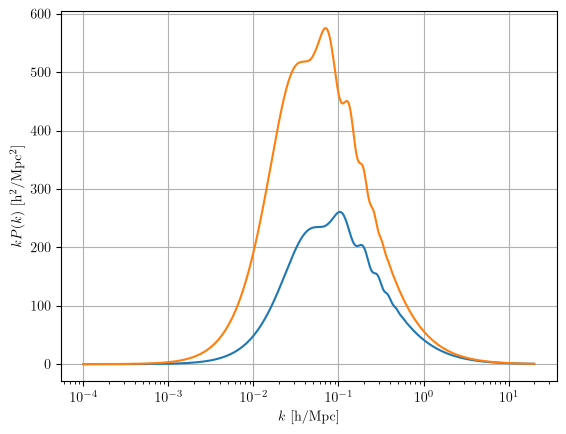

In [2]:
plt.plot(klin, klin*Plin)
plt.plot(klin2, klin2*Plin2)

plt.xscale('log')
plt.xlabel(r'$k$ [h/Mpc]')
plt.ylabel(r'$kP(k)$ [h$^2$/Mpc$^2$]')
plt.grid(True)
plt.show()

In [7]:
with h5.File("/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150.hdf5", "r") as hdf:
    xihh   = np.array(hdf['xi'][()])
    r      = np.array(hdf['r_cens'][()])
    sigma2 = np.diag(hdf['xi_cov'][()])

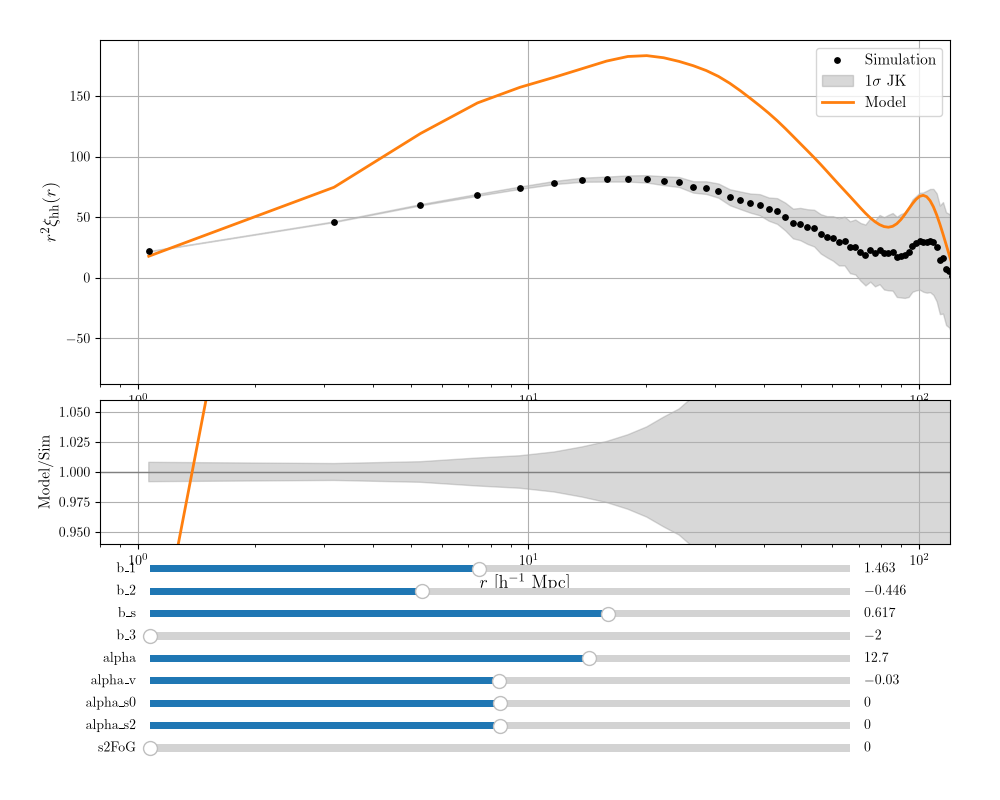

/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx

In [8]:
%matplotlib widget

interactive_xihh(r, xihh, sigma2, gsm)

In [ ]:
best = [1.463, -0.446, 0.617, -2, 12.7, -0.03, 0, 0, 0]